<!-- Contenedor -->
<div style="max-width:1100px; margin:0 auto;">

  <!-- Dos columnas: izquierda (imágenes), derecha (texto) -->
  <div style="display:flex; align-items:flex-start; gap:1.25rem; margin:1rem 0; flex-wrap:wrap;">
    <!-- Columna izquierda: dos imágenes, mismo ancho, pegadas -->
    <div style="width:20%; min-width:240px; line-height:0;">
      <!-- Imagen 1 -->
      <img
        src="https://cdn.prod.website-files.com/617960145ff34f911afe7243/66f59b40faae94506a4cc751_66f59b0f18152ddb1f3228ab_Automated%2520Trading.jpeg"
        alt="Imagen 1"
        style="width:100%; display:block; margin:0; border:0;" />
      <!-- Imagen 2 con fondo blanco (sin separación) -->
      <div style="background:#fff; margin:0;">
        <img
          src="https://www.ehu.eus/documents/51299803/52066233/Logo-UPV-EHU.png/ce57c7e3-c62b-3b9f-d1a6-395d384f6c2b?t=1710766509885"
          alt="Imagen 2"
          style="width:100%; display:block; margin:0; border:0;" />
      </div>
    </div> 
    <!-- Columna derecha: texto alineado en el mismo margen -->
    <div style="flex:1; min-width:300px; text-align:left;">
      <div style="margin:0; font-size:1.45rem; font-weight:700; line-height:1.15;">
        TRABAJO FINAL DE MÁSTER
      </div>
      <div style="margin:0.65rem 0 0 0; font-size:1.30rem; font-weight:600; line-height:1.2; opacity:0.95;">
        Máster en Finanzas y Dirección Financiera
      </div>
      <div style="margin:1.8rem 0 0 0; font-size:1.10rem; font-weight:600; line-height:1.35;">
        Bots de trading inteligentes: estrategias adaptativas impulsadas por <em>machine learning</em> para la optimización de carteras en renta variable, divisas y criptoactivos
      </div>
      <div style="margin-top:1.8rem; font-size:1rem;">
        <p style="margin:0.2rem 0;"><strong>Autor:</strong> Karen Fajardo</p>
        <p style="margin:0.2rem 0;"><strong>Tutor:</strong> PhD. Vicente Ruiz</p>
      </div>
    </div>

  </div>

  <hr style="margin:1.25rem 0;" />
</div>



### Tabla de contenidos
1. [Entorno y dependencias](#1-entorno-y-dependencias)  
2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips)  
3. [Universo de activos & datos](#3-universo-de-activos--datos)  
4. [Features & Scoring ML](#4-features--scoring-ml)  
5. [Construcción de cartera (medio plazo)](#5-construcción-de-cartera-medio-plazo)  
6. [Validación walk-forward & métricas](#6-validación-walk-forward--métricas)  
7. [Paper trading multi-activo](#7-paper-trading-multi-activo)  
8. [Selección para intradía](#8-selección-para-intradia)  
9. [Resultados, conclusiones y limitaciones](#9-resultados-conclusiones-y-limitaciones)  
10. [Reproducibilidad](#10-reproducibilidad)  


---

### 1. [Entorno y dependencias](#1-entorno-y-dependencias)
Para garantizar la **reproducibilidad** y un flujo de trabajo ordenado, se configuró un entorno virtual en **Python 3.11** con todas las librerías necesarias fijadas en un `requirements.txt`.

- **Entorno virtual (`.venv`)**: aísla las dependencias del proyecto y evita conflictos con otras instalaciones de Python.  
- **Archivo `.env`**: centraliza variables sensibles y de configuración (ej. semillas aleatorias, rutas de datos, claves API).  
- **Semillas globales**: aseguran resultados consistentes en pruebas y entrenamientos de modelos.  
- **Rutas (`settings.py`)**: se definen directorios estándar para `data/`, `models/`, `logs/` y `reports/`, evitando rutas “hardcodeadas”.  
- **Bootstrap**: función que inicializa el proyecto cargando el `.env`, aplicando zona horaria, fijando semillas y creando carpetas.  

Esto permite que cualquier usuario pueda **replicar el entorno** simplemente creando el entorno virtual e instalando dependencias desde `requirements.txt`.
Ademas, se implementó un flujo de trabajo basado en **Git** para gestionar cambios y mantener el historial del proyecto de forma estructurada y con un esquema que permite que cualquier colaborador pueda clonar el proyecto, instalar las dependencias y reproducir el entorno de forma consistente.

In [1]:
# Añadir la RAÍZ del proyecto al sys.path para que 'settings' sea importable
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/)")

PROJECT_ROOT = find_project_root(Path.cwd())

# 1) Raíz del repo (para importar 'settings')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2) src/ (para importar 'tfm')
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)


PROJECT_ROOT: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading
SRC_DIR: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\src


In [2]:
import numpy as np
from tfm.bootstrap import bootstrap

seed_used = bootstrap()  
print(f"Entorno inicializado. Seed efectiva: {seed_used}")

# Comprobamos que settings se ve correctamente
import importlib, os
settings = importlib.import_module("settings")
print("TZ:", os.environ.get("TZ"))
print("DATA_DIR:", getattr(settings, "DATA_DIR", None))
print("MODELS_DIR:", getattr(settings, "MODELS_DIR", None))
print("LOGS_DIR:", getattr(settings, "LOGS_DIR", None))



Entorno inicializado. Seed efectiva: 42
TZ: Europe/Madrid
DATA_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data
MODELS_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\models
LOGS_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\logs


### 2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips) 

In [3]:
import yaml, math
from pathlib import Path
import pandas as pd



def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/).")

try:
    PROJECT_ROOT  # ya definido
except NameError:
    PROJECT_ROOT = find_project_root(Path.cwd())

IPS_PATH = PROJECT_ROOT / "config" / "ips.yaml"
print("IPS_PATH:", IPS_PATH)

required = ["investor_profile","objectives","risk_metrics","restrictions","universes","rebalancing"]
raw = yaml.safe_load(IPS_PATH.read_text(encoding="utf-8"))
missing = [k for k in required if k not in raw]
assert not missing, f"Faltan claves en ips.yaml: {missing}"

r = raw["restrictions"]
assert 0 <= r["min_cash"] <= r["max_cash"] <= 1.0, "Rango de caja inválido."
vol = raw["risk_metrics"]
assert vol["target_volatility"] < vol["max_volatility"], "target_volatility debe ser < max_volatility."

# Resúmenes auditables
perfil = pd.Series(raw["investor_profile"], name="Perfil del inversor").to_frame()
objet  = pd.Series(raw["objectives"],       name="Objetivos").to_frame()
riesgo = pd.Series(raw["risk_metrics"],     name="Métricas de riesgo").to_frame()
techos = pd.Series(raw["restrictions"].get("max_asset_class_weight", {}), name="Techos por clase").to_frame()

display(perfil, objet, riesgo, techos)
raw


IPS_PATH: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\config\ips.yaml


,Perfil del inversor
type,dynamic
risk_tolerance,high
horizon,medium_term
currency,EUR


,Objetivos
target_return,0.12
sharpe_min,1.00


,Métricas de riesgo
target_volatility,0.12
max_volatility,0.18
max_drawdown,0.20


,Techos por clase
equities,0.60
forex,0.25
crypto,0.05


{'investor_profile': {'type': 'dynamic',
  'risk_tolerance': 'high',
  'horizon': 'medium_term',
  'currency': 'EUR'},
 'objectives': {'target_return': 0.12, 'sharpe_min': 1.0},
 'risk_metrics': {'target_volatility': 0.12,
  'max_volatility': 0.18,
  'max_drawdown': 0.2},
 'restrictions': {'max_asset_weight': 0.2,
  'leverage': False,
  'min_cash': 0.05,
  'max_cash': 0.1,
  'cap_mode': 'budgeted',
  'max_asset_class_weight': {'equities': 0.6, 'forex': 0.25, 'crypto': 0.05},
  'max_position_value_eur': 50000},
 'universes': {'equities': True, 'forex': True, 'crypto': True},
 'rebalancing': {'frequency': 'monthly'}}

In [4]:
#Establecemos una formula de validación que asegura que la configuración del perfil del inversor en el YAML sea factible y consistente con las 
#restricciones de presupuesto y liquidez antes de que la optimización de cartera arranque. Esto se conecta con la literatura de risk budgeting 
#y portfolio constraints: un paso fundamental en la gestión cuantitativa es detectar y corregir configuraciones imposibles o que violan 
#restricciones lógicas, ya que de otro modo la optimización se rompe o produce resultados irreales

#Verificar las restricciones de cash , pesos asignados a los activos y se establecen mensajes de errores. 


def validate_ips_budgeted_with_cash(ips: dict):
    errors = []
    r = ips.get("restrictions", {})
    rm = ips.get("risk_metrics", {})

    # --- Riesgo ---
    tv = rm.get("target_volatility")
    mv = rm.get("max_volatility")
    if tv is None or mv is None:
        errors.append("Define 'risk_metrics.target_volatility' y 'risk_metrics.max_volatility'.")
    else:
        if tv < 0 or mv < 0:
            errors.append("Volatilidades deben ser no negativas.")
        if tv > mv:
            errors.append(f"target_volatility ({tv:.2%}) no puede superar max_volatility ({mv:.2%}).")

    # --- Cash ---
    min_cash = r.get("min_cash", 0.0)
    max_cash = r.get("max_cash", 0.0)
    if not (0 <= min_cash <= 1 and 0 <= max_cash <= 1):
        errors.append("min_cash y max_cash deben estar entre 0 y 1.")
    if min_cash > max_cash:
        errors.append(f"min_cash ({min_cash:.0%}) no puede ser mayor que max_cash ({max_cash:.0%}).")

    # --- Peso por activo ---
    maw = r.get("max_asset_weight")
    if maw is None or not (0 < maw <= 1):
        errors.append("max_asset_weight debe estar en (0,1].")

    # --- Cuotas por clase (budgeted y máximos) ---
    cap_mode = r.get("cap_mode", "independent")
    macw = r.get("max_asset_class_weight", {})
    if cap_mode != "budgeted":
        errors.append("cap_mode debe ser 'budgeted' para cuotas presupuestadas y máximos.")
    if not macw:
        errors.append("Define 'restrictions.max_asset_class_weight' para 'budgeted'.")
    else:
        # cuotas en [0,1]
        if any((w is None) or (w < 0) or (w > 1) for w in macw.values()):
            errors.append("Cada cuota en 'max_asset_class_weight' debe estar en [0,1].")

        total_quota = sum(macw.values())

        # Factibilidad con bandas de cash:
        # Debe cumplirse: 1 - max_cash <= sum(quota) <= 1 - min_cash
        lower = 1 - max_cash
        upper = 1 - min_cash
        if total_quota + 1e-9 < lower:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) < 1 - max_cash ({lower:.2%}). "
                "Aumenta cuotas o reduce max_cash."
            )
        if total_quota - 1e-9 > upper:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) > 1 - min_cash ({upper:.2%}). "
                "Reduce cuotas o disminuye min_cash."
            )

    if errors:
        raise ValueError("Errores en IPS:\n- " + "\n- ".join(errors))

    # Avisos útiles (no bloquean)
    total_quota = sum(macw.values())
    if abs(total_quota - (1 - min_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - min_cash: la cartera tenderá a mantener el mínimo de cash.")
    if abs(total_quota - (1 - max_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - max_cash: la cartera podría forzar el cash máximo con facilidad.")



### 3. [Universo de activos & datos](#3-universo-de-activos--datos)  
Definimos y validamos el universo de activos financieros a considerar en la optimización de cartera. 
Esto incluye la carga de datos históricos, la verificación de la integridad y calidad de los datos, y la categorización de los activos en clases (acciones, bonos, materias primas, etc.). 
Un universo bien definido es crucial para asegurar que la optimización de cartera se base en información precisa y relevante, 
permitiendo una mejor diversificación y alineación con los objetivos del inversor. 

In [5]:
import yfinance as yf 
import datetime as dt
from pathlib import Path
import yaml
import pyarrow as pa
import warnings
import missingno as msno
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [6]:
print("Descargando datos actualizados desde Yahoo Finance (OHLCV)")

years_of_data = 2
# 1. Fechas
START_DATE = (dt.date.today() - dt.timedelta(days=365*years_of_data)).strftime("%Y-%m-%d")
END_DATE = dt.date.today().strftime("%Y-%m-%d")

# 2. Cargar universo de tickers
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
symbols_yf = [x["symbol_yf"] for x in universe["tickers"]]

print(f"Tickers totales a descargar: {len(symbols_yf)}")

# 3. Descarga completa OHLCV
raw = yf.download(
    tickers=symbols_yf,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="ticker",
    progress=False
)

# 4. Construir estructura final con todas las columnas por ticker
full_data = {}

for ticker in symbols_yf:
    try:
        df_t = raw[ticker][["Open", "High", "Low", "Close", "Adj Close", "Volume"]]
        full_data[ticker] = df_t
    except:
        print(f"[WARN] {ticker}: no descargado")

# 5. Crear un MultiIndex DataFrame: niveles → Fecha × (Ticker, Campo)
prices_df = pd.concat(full_data, axis=1)

print("Descarga completada. Dimensiones:", prices_df.shape)

prices_df.head()


Descargando datos actualizados desde Yahoo Finance (OHLCV)
Tickers totales a descargar: 98
Descarga completada. Dimensiones: (523, 588)


BMNR                                        TSLA              \
Price      Open High Low Close Adj Close Volume        Open        High   
Date                                                                      
2023-11-15  NaN  NaN NaN   NaN       NaN    NaN  239.289993  246.699997   
2023-11-16  NaN  NaN NaN   NaN       NaN    NaN  239.490005  240.880005   
2023-11-17  NaN  NaN NaN   NaN       NaN    NaN  232.000000  237.389999   
2023-11-20  NaN  NaN NaN   NaN       NaN    NaN  234.039993  237.100006   
2023-11-21  NaN  NaN NaN   NaN       NaN    NaN  235.039993  243.619995   

                                    ...         TD                        \
Price              Low       Close  ...        Low      Close  Adj Close   
Date                                ...                                    
2023-11-15  236.449997  242.839996  ...  61.189999  61.290001  56.200100   
2023-11-16  230.960007  233.589996  ...  60.669998  60.900002  55.842495   
2023-11-17  226.539993  234.300003  ...  61.270000  61.820000  56.686085   
2023-11-20  231.020004  235.600006  ...  61.400002  62.009998  56.860306   
2023-11-21  233.339996  241.199997  ...  61.430000  61.490002  56.383495   

                              RY                                              \
Price          Volume       Open       High        Low      Close  Adj Close   
Date                                                                           
2023-11-15  1692900.0  87.459999  88.120003  87.110001  87.610001  82.165329   
2023-11-16  1341400.0  87.279999  87.510002  86.750000  87.010002  81.602623   
2023-11-17  1703400.0  87.589996  88.269997  87.500000  88.000000  82.531097   
2023-11-20  1629300.0  87.699997  88.250000  87.379997  87.830002  82.371666   
2023-11-21  2281500.0  87.779999  88.360001  87.309998  87.440002  82.005890   

                       
Price          Volume  
Date                   
2023-11-15  1047400.0  
2023-11-16  1006300.0  
2023-11-17   884600.0  
2023-11-20   809500.0  
2023-11-21   946800.0  

[5 rows x 588 columns]

In [7]:
#Df inciial para futura validación de los resultados 
print("Guardado de respaldo (snapshot) de precios OHLCV.")

snapshot_dir = PROJECT_ROOT / "data" / "snapshots"
snapshot_dir.mkdir(parents=True, exist_ok=True)

snapshot_name = f"prices_OHLCV_{dt.date.today().strftime('%Y%m%d')}.csv.gz"
snapshot_path = snapshot_dir / snapshot_name

prices_df.to_csv(snapshot_path, compression="gzip")
print("Snapshot creado correctamente en:", snapshot_path)


Guardado de respaldo (snapshot) de precios OHLCV.
Snapshot creado correctamente en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\snapshots\prices_OHLCV_20251114.csv.gz


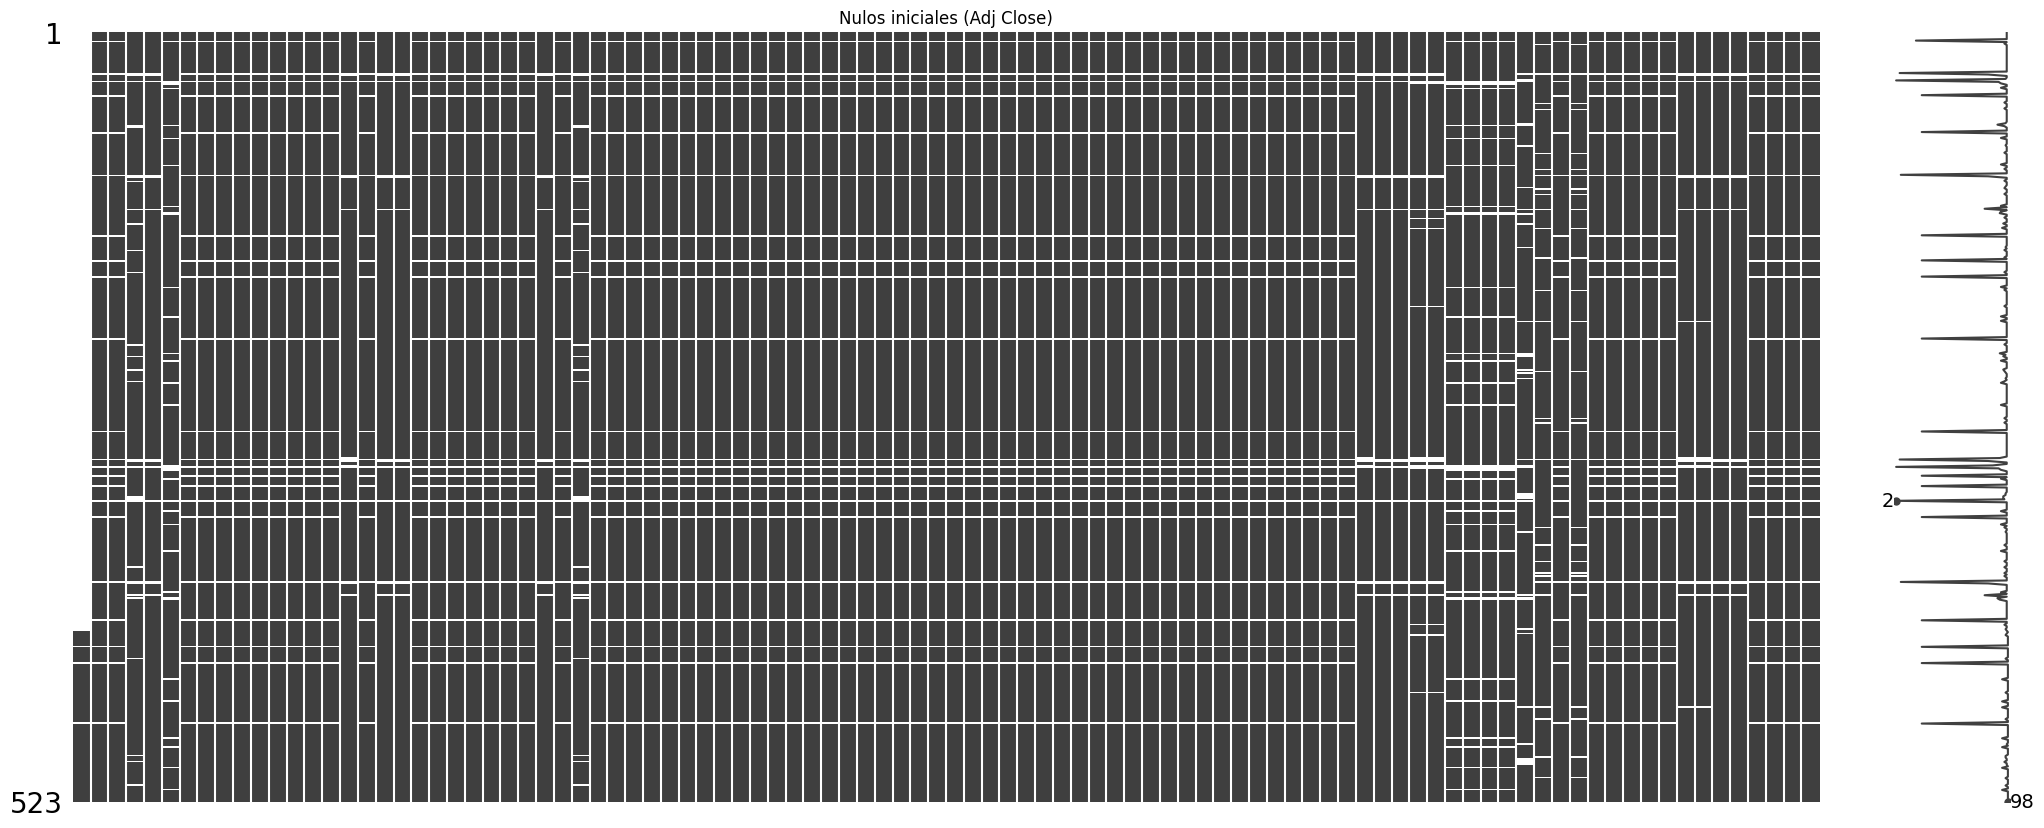

In [8]:
# Extraer OHLCV del MultiIndex
open_df   = prices_df.xs("Open", level=1, axis=1).copy()
high_df   = prices_df.xs("High", level=1, axis=1).copy()
low_df    = prices_df.xs("Low", level=1, axis=1).copy()
close_df  = prices_df.xs("Close", level=1, axis=1).copy()
adj_df    = prices_df.xs("Adj Close", level=1, axis=1).copy()
vol_df    = prices_df.xs("Volume", level=1, axis=1).copy()

# Podemos visualizar solo AdjClose (que resume bien los nulos)
msno.matrix(adj_df)
plt.title("Nulos iniciales (Adj Close)")
plt.show()

In [9]:
# Eliminar activos con >10% nulos en Adj Close 
porcentaje_nulos = adj_df.isna().mean()

tickers_ok = porcentaje_nulos[porcentaje_nulos < 0.10].index
tickers_bad = porcentaje_nulos[porcentaje_nulos >= 0.10].index

print("Activos eliminados (+10% nulos):")
print(list(tickers_bad))

# Filtrar en TODAS las tablas OHLCV
open_df   = open_df[tickers_ok]
high_df   = high_df[tickers_ok]
low_df    = low_df[tickers_ok]
close_df  = close_df[tickers_ok]
adj_df    = adj_df[tickers_ok]
vol_df    = vol_df[tickers_ok]


Activos eliminados (+10% nulos):
['BMNR']


In [10]:
# Unir todas las columnas para detectar días con NaN en cualquier activo o columna
full_matrix = pd.concat(
    [open_df, high_df, low_df, close_df, adj_df, vol_df],
    axis=1
)

# Fechas válidas (sin ningún NaN)
valid_rows = full_matrix.dropna(axis=0, how='any').index

# Aplicar el filtro
open_df   = open_df.loc[valid_rows]
high_df   = high_df.loc[valid_rows]
low_df    = low_df.loc[valid_rows]
close_df  = close_df.loc[valid_rows]
adj_df    = adj_df.loc[valid_rows]
vol_df    = vol_df.loc[valid_rows]

indices_p = adj_df.copy()
print("Después de limpieza total, dimensiones finales:", indices_p.shape)
  

Después de limpieza total, dimensiones finales: (400, 97)


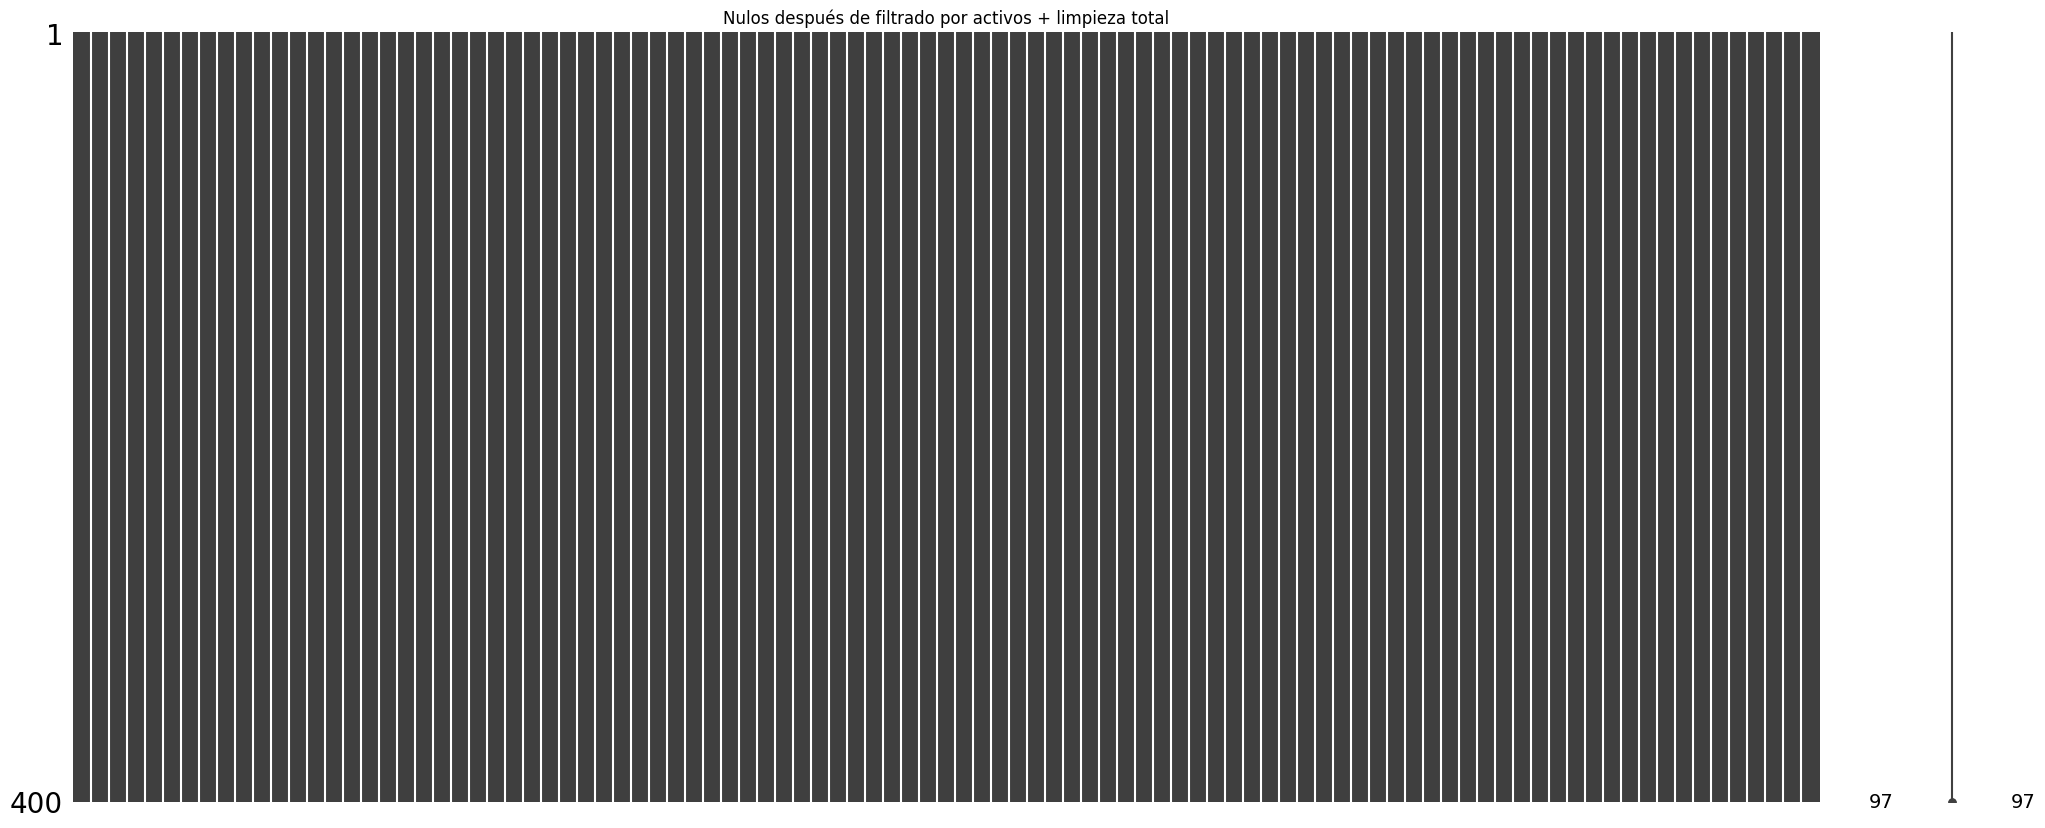

In [11]:
msno.matrix(adj_df)
plt.title("Nulos después de filtrado por activos + limpieza total")
plt.show()


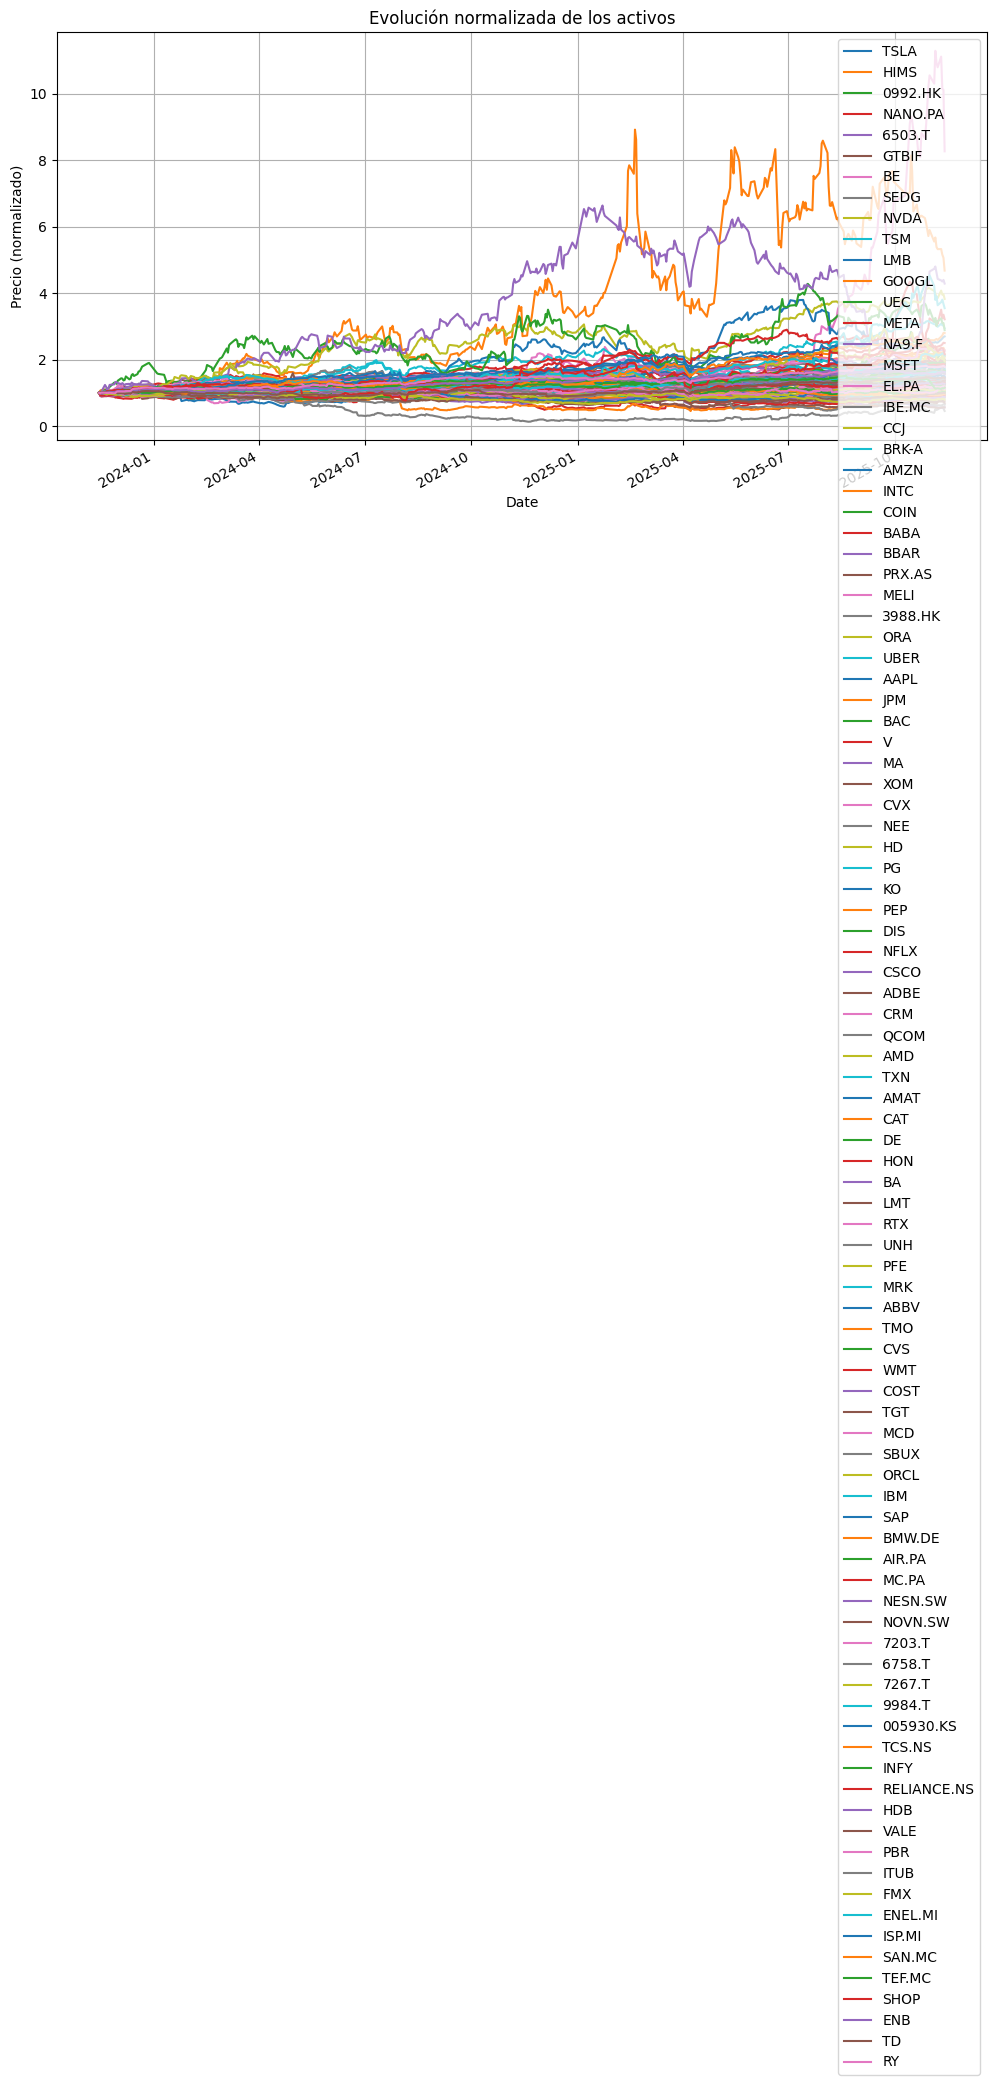

In [12]:
#Grafica de la evolución normalizada de los precios de los activos
indices_p = indices_p.dropna(axis=0, how='any')

activos_precios = indices_p / indices_p.iloc[0, :]

activos_precios.plot(figsize=(12, 6))
plt.title("Evolución normalizada de los activos")
plt.ylabel("Precio (normalizado)")
plt.grid(True)
plt.show()


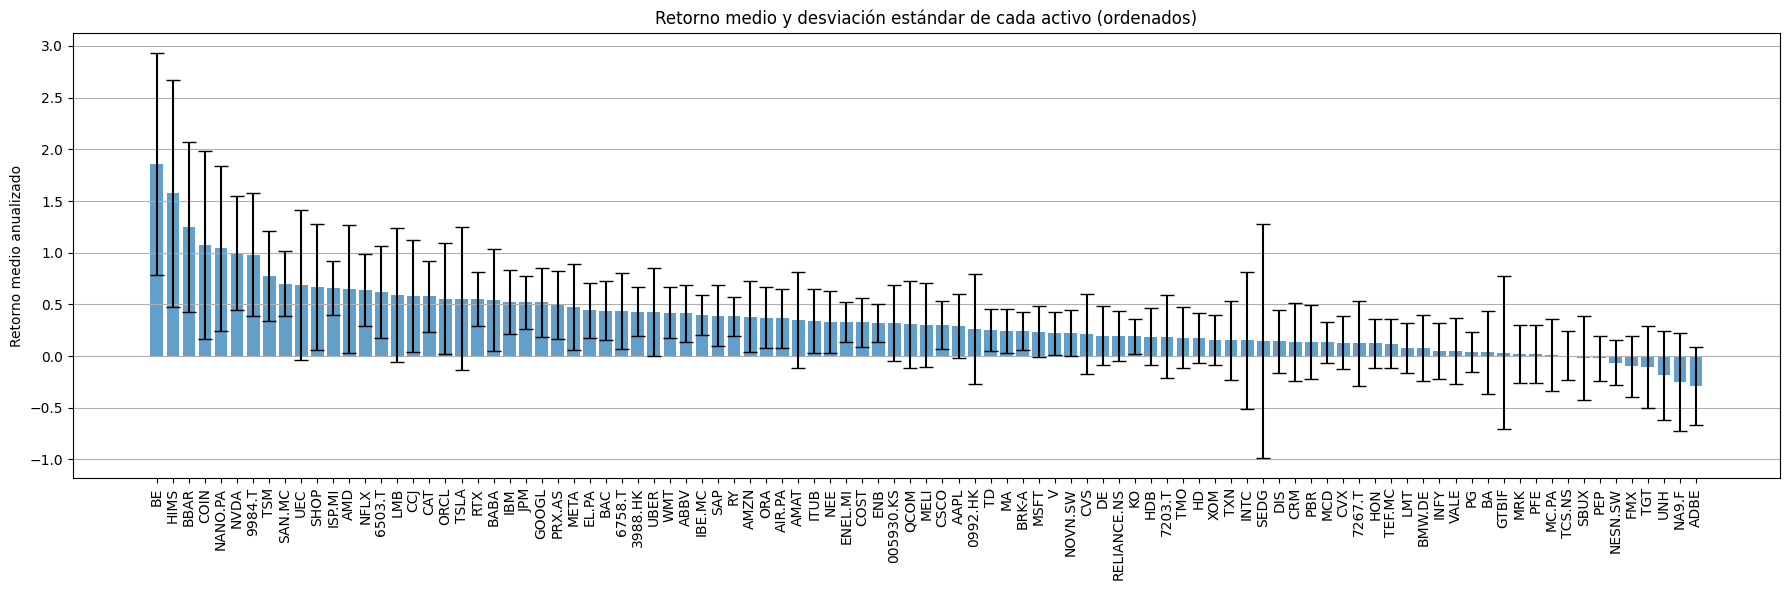

In [13]:
# Cálculo de retornos diarios, media anualizada y desviación estándar anualizada
retornos_activos = indices_p.pct_change().dropna()

# ==== Métricas anualizadas ====
media = retornos_activos.mean() * 252
desviacion = retornos_activos.std() * np.sqrt(252)

# ==== Sharpe simple (sin RF por ahora) ====
sharpe = media / desviacion

# ==== Ordenamiento por retorno ====
orden = media.sort_values(ascending=False).index
media_sorted = media[orden]
desviacion_sorted = desviacion[orden]

#Volumen medio diario
volumen = vol_df.mean()


plt.figure(figsize=(18, 6))
plt.bar(media_sorted.index, media_sorted.values, 
        yerr=desviacion_sorted.values, 
        capsize=5, alpha=0.7)

plt.xticks(rotation=90)
plt.ylabel('Retorno medio anualizado')
plt.title('Retorno medio y desviación estándar de cada activo (ordenados)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [14]:
# Cargar universo y clasificar por región, para visualizar mejor los resultados 
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
df_universe = pd.DataFrame(universe["tickers"])

# Clasificación por región
def map_region(country):
    country = country.lower()

    if country in ["usa", "united states"]:
        return "usa"
    if country in ["china", "hong kong"]:
        return "china"
    if country in ["spain", "france", "germany", "italy", "netherlands", "switzerland"]:
        return "europe"
    if country in ["japan", "india", "south korea", "taiwan"]:
        return "asia"
    if country in ["brazil", "mexico", "argentina"]:
        return "latam"
    return "other"

df_universe["region"] = df_universe["country"].apply(map_region)

# Agrupar símbolos por región
regiones = (
    df_universe.groupby("region")["symbol_yf"]
    .apply(list)
    .to_dict()
)

color_map = {
    "usa": "#1f77b4",      # azul
    "china": "#ff7f0e",    # naranja
    "europe": "#2ca02c",   # verde
    "asia": "#9467bd",     # púrpura
    "latam": "#d62728",    # rojo
    "other": "#7f7f7f"     # gris
}


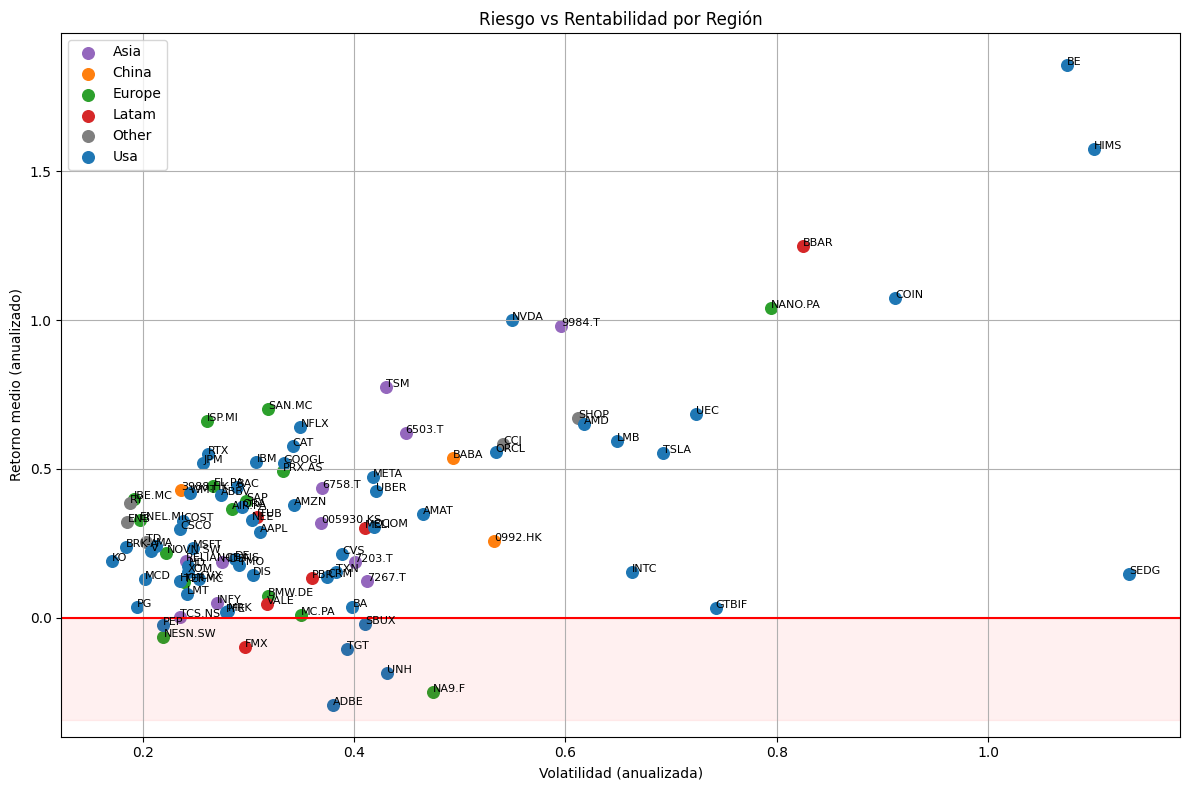

In [15]:
# Gráfico Riesgo vs Rentabilidad por región
plt.figure(figsize=(12, 8))

for region, tickers in regiones.items():

    tickers_validos = [t for t in tickers if t in media.index]

    plt.scatter(
        desviacion[tickers_validos],
        media[tickers_validos],
        color=color_map[region],
        label=region.capitalize(),
        s=70
    )

# Línea roja en y=0
plt.axhline(0, color='red', linewidth=1.5)

# Sombreado rojo bajo cero
plt.axhspan(min(media)-0.05, 0, color='red', alpha=0.06)

# Etiquetas
for t in media.index:
    plt.text(desviacion[t], media[t], t, fontsize=8)

plt.xlabel("Volatilidad (anualizada)")
plt.ylabel("Retorno medio (anualizado)")
plt.title("Riesgo vs Rentabilidad por Región")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Preparación de features para clustering “cartera eficiente”
features_port = pd.DataFrame({
    "mean": media,
    "vol": desviacion,
    "volume": volumen,
    "sharpe": sharpe
}).dropna()

scaler_port = StandardScaler()
X_port = scaler_port.fit_transform(features_port)

kmeans_port = KMeans(n_clusters=4, random_state=42)
features_port["cluster_port"] = kmeans_port.fit_predict(X_port)

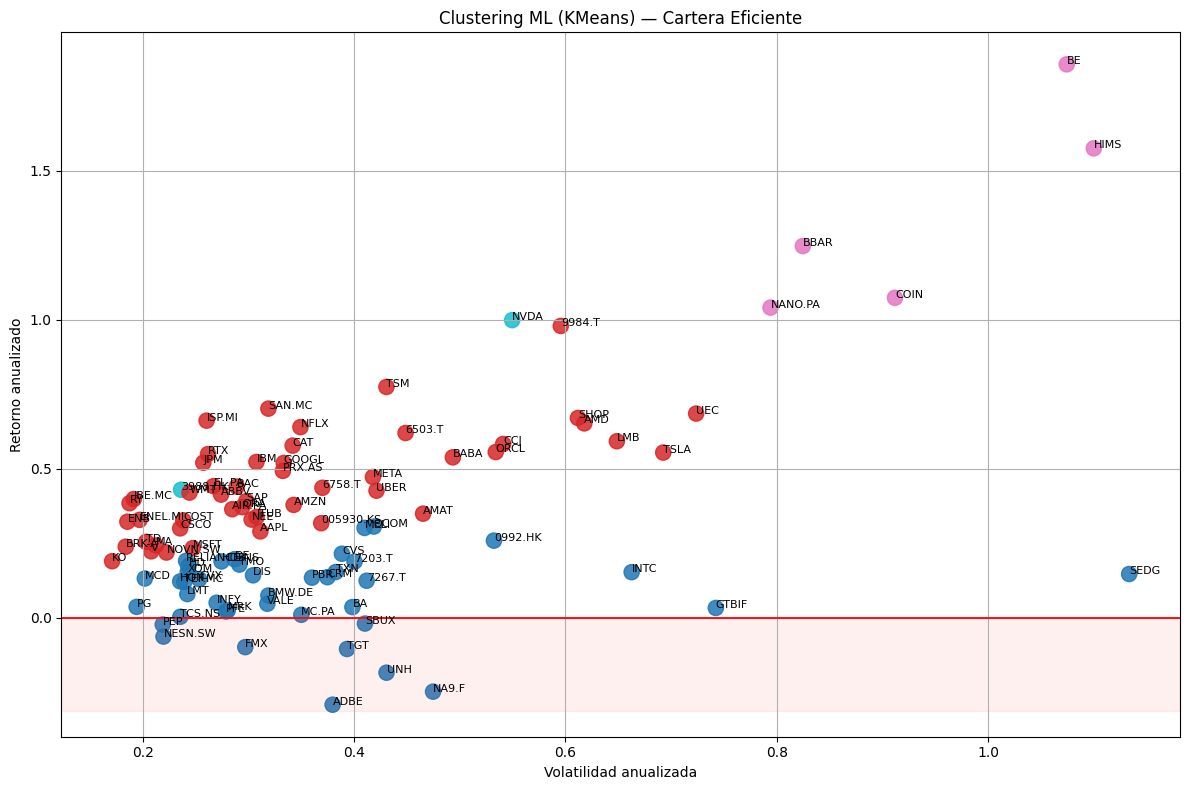

In [17]:
#Grafico del clustering de cartera eficiente 
plt.figure(figsize=(12, 8))

# scatter coloreado por CLUSTER
plt.scatter(
    features_port["vol"],
    features_port["mean"],
    c=features_port["cluster_port"],
    cmap="tab10",
    s=120,
    alpha=0.85
)

# Etiquetas con nombre del ticker
for ticker in features_port.index:
    plt.text(
        features_port.loc[ticker, "vol"],
        features_port.loc[ticker, "mean"],
        ticker,
        fontsize=8
    )

# Línea horizontal en y = 0
plt.axhline(0, color='red', linewidth=1.3)

# Sombreado rojo (rentabilidad negativa)
plt.axhspan(features_port["mean"].min() - 0.02, 0,
            color='red', alpha=0.06)

plt.xlabel("Volatilidad anualizada")
plt.ylabel("Retorno anualizado")
plt.title("Clustering ML (KMeans) — Cartera Eficiente")
plt.grid(True)
plt.tight_layout()
plt.show()



In [18]:
features_summary = features_port.groupby("cluster_port").agg({
    "mean": ["mean", "median"],
    "vol": ["mean", "median"],
    "sharpe": ["mean", "median"],
    "volume": ["mean", "median"]
})


#Lista de los activos en el cluster 2
activos_cluster_2 = features_port[features_port["cluster_port"] == 3].index.tolist()
print("Activos en el cluster 2 (Cartera Eficiente):")
print(activos_cluster_2)


Activos en el cluster 2 (Cartera Eficiente):
['NVDA', '3988.HK']


In [19]:
#Añadimos sector y regi{on desde el YAML
df_universe = pd.DataFrame(universe["tickers"])

sector_map = df_universe.set_index("symbol_yf")["sector"]
region_map = df_universe.set_index("symbol_yf")["country"].apply(map_region)

features_port["sector"] = features_port.index.map(sector_map).fillna("other")
features_port["region"] = features_port.index.map(region_map).fillna("other")


In [20]:
#SELECCIÓN ´PRELIMINAR POR SHARPE + DIVERSIFICACION DE SECTOR Y REGIÓN
df_candidates = features_port.sort_values(by="sharpe", ascending=False)

selected = []
sector_counts = {}
region_counts = {}

max_sector = 2
max_region = 2
max_total = 25

for ticker, row in df_candidates.iterrows():

    sec = row["sector"]
    reg = row["region"]

    if sector_counts.get(sec, 0) >= max_sector:
        continue
    if region_counts.get(reg, 0) >= max_region:
        continue
    if len(selected) >= max_total:
        break

    selected.append(ticker)
    sector_counts[sec] = sector_counts.get(sec, 0) + 1
    region_counts[reg] = region_counts.get(reg, 0) + 1



In [21]:
#MATRIZ DE RETORNOS DEL UNIVERSO SELECCIONADO
df_selected = df_candidates.loc[selected]

returns_selected = retornos_activos[df_selected.index]
returns_selected.tail()



,ISP.MI,SAN.MC,RTX,NFLX,TSM,ENB,9984.T,SHOP,BABA,MELI,0992.HK,PBR
Date,,,,,,,,,,,,
2025-11-07,-0.000717,-0.010511,0.010680,0.006053,-0.009473,0.017705,-0.068670,-0.023326,-0.007577,-0.009270,-0.013310,0.059308
2025-11-10,0.035535,0.036727,0.011640,0.014869,0.030611,0.004402,0.025576,0.042451,-0.002705,-0.007854,-0.011691,0.011664
2025-11-11,0.013345,0.014716,0.001061,0.014615,-0.013886,0.007721,0.019771,0.000378,-0.030683,0.003599,-0.012739,0.035357
2025-11-12,0.015906,0.027393,-0.008537,0.018532,-0.001889,0.008697,-0.034589,-0.014785,-0.017973,0.002067,0.012903,-0.036377
2025-11-13,0.006734,-0.001464,-0.020992,-0.002825,-0.028972,-0.009238,-0.033775,-0.065458,0.012222,-0.034631,-0.011829,0.003852


In [22]:
#HRP (Hierarchical Risk Parity) – Implementación
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

def correl_to_dist(corr):
    return ((1 - corr) / 2) ** 0.5

corr = returns_selected.corr()
dist = correl_to_dist(corr)

# clustering jerárquico
link = linkage(squareform(dist), method="ward")



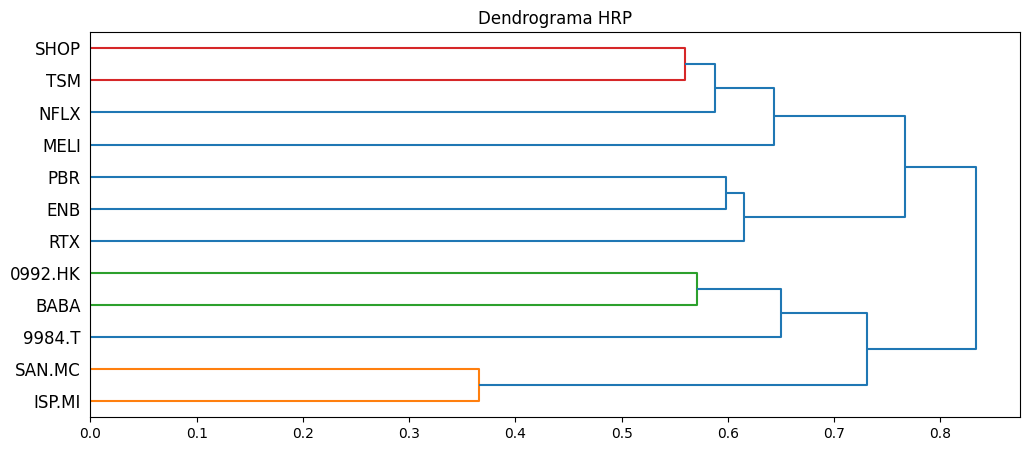

In [23]:
plt.figure(figsize=(12, 5))
dendrogram(link, labels=returns_selected.columns, orientation='right')
plt.title("Dendrograma HRP")
plt.show()


In [24]:
#Quasi-diagonalization (ordenación óptima de activos)
def get_quasi_diag(link):
    link = link.astype(int)
    n = link[-1, 3]  # número total de elementos
    cluster = [int(link[-1, 0]), int(link[-1, 1])]
    
    # expandir recursivamente
    items = []
    while len(cluster) > 0:
        i = cluster.pop(0)
        if i < n:
            items.append(i)
        else:
            i -= n
            cluster = [int(link[i, 0]), int(link[i, 1])] + cluster
    return items


In [25]:
#Asignación de pesos por Recursive Bisection
def get_hrp_weights(cov, ordered_tickers):
    weights = pd.Series(1, index=ordered_tickers)
    clusters = [ordered_tickers]

    while len(clusters) > 0:
        cluster = clusters.pop(0)
        if len(cluster) <= 1:
            continue
        
        # dividir en 2 mitades
        split = len(cluster) // 2
        left = cluster[:split]
        right = cluster[split:]

        # varianzas
        cov_l = cov.loc[left, left].values
        cov_r = cov.loc[right, right].values
        
        var_l = np.dot(np.dot(np.ones(len(cov_l)), cov_l), np.ones(len(cov_l)))
        var_r = np.dot(np.dot(np.ones(len(cov_r)), cov_r), np.ones(len(cov_r)))

        alpha = 1 - var_l / (var_l + var_r)

        weights[left] = weights[left] * alpha
        weights[right] = weights[right] * (1 - alpha)

        clusters.append(left)
        clusters.append(right)

    return weights / weights.sum()


In [26]:
#Ejecución del HRP y obtención de pesos finales
cov = returns_selected.cov()

# Orden óptimo HRP
ordered_idx = get_quasi_diag(link)
ordered_tickers = returns_selected.columns[ordered_idx]

# Pesos finales HRP
weights_hrp = get_hrp_weights(cov, ordered_tickers)
weights_hrp


ISP.MI     0.217569
SAN.MC     0.020937
9984.T     0.006005
BABA       0.144068
0992.HK    0.017527
RTX        0.072437
ENB        0.339078
PBR        0.019219
MELI       0.014838
NFLX       0.127731
TSM        0.013769
SHOP       0.006822
dtype: float64

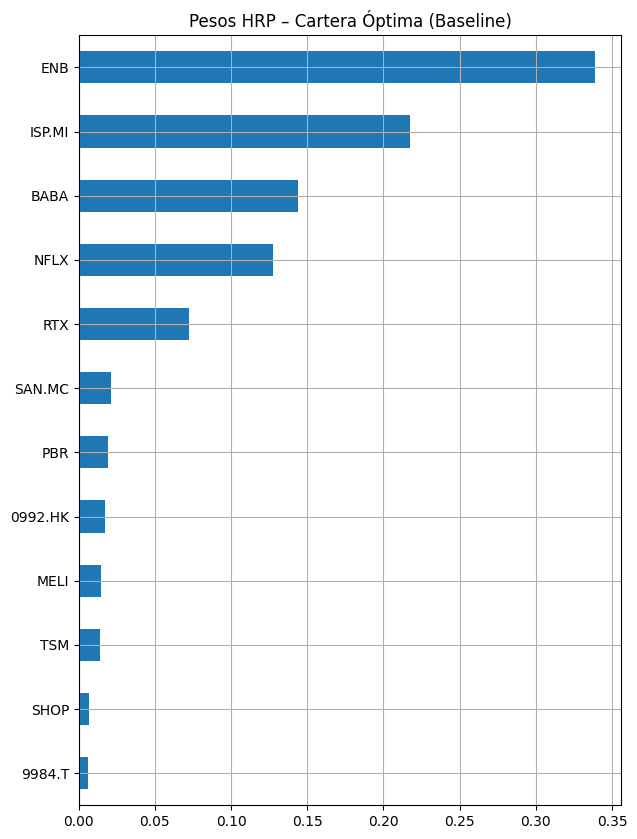

In [27]:
weights_hrp.sort_values().plot(kind='barh', figsize=(7, 10))
plt.title("Pesos HRP – Cartera Óptima (Baseline)")
plt.grid(True)
plt.show()


In [28]:
#Detalle de los activos, nombre de empresa, sector y región de los activos pesos seleccionados en la cartera óptima
#Ordenados por peso asignado

activos_cartera_optima = pd.DataFrame({
    "weight": weights_hrp,
    "sector": df_universe.set_index("symbol_yf").loc[weights_hrp.index, "sector"],
    "region": df_universe.set_index("symbol_yf").loc[weights_hrp.index, "country"].apply(map_region),
    "name": df_universe.set_index("symbol_yf").loc[weights_hrp.index, "name"]
}).sort_values(by="weight", ascending=False)

activos_cartera_optima

,weight,sector,region,name
ENB,0.339078,Energy / Pipelines,other,Enbridge
ISP.MI,0.217569,Financial,europe,Intesa Sanpaolo
BABA,0.144068,E-Commerce / Technology,china,Alibaba Group (ADR)
NFLX,0.127731,Entertainment / Streaming,usa,Netflix
RTX,0.072437,Defense,usa,RTX Corp
SAN.MC,0.020937,Financial,europe,Banco Santander
PBR,0.019219,Energy,latam,Petrobras
0992.HK,0.017527,Technology / Hardware,china,Lenovo Group
MELI,0.014838,E-Commerce / Payments,latam,MercadoLibre
TSM,0.013769,Semiconductors,asia,Taiwan Semiconductor (ADR)


In [30]:
#PREPARACIÓN DEL MODELO SUPERVISADO (ML)
#Construcción de data set, 25 dias para test 
test_size = 25

returns_full = retornos_activos.copy()

returns_train = returns_full.iloc[:-test_size]
returns_test  = returns_full.iloc[-test_size:]

#Generar retornos mensuales adelantados como target (y)
# retorno mensual adelantado (21 días aprox)
y = returns_train.rolling(window=21).sum().shift(-21)
y = y.dropna()

In [ ]:
# 1. Convertir matriz returns_train (374 × 97) en formato panel (Date, Asset)
panel = returns_train.stack().to_frame("ret")
panel.index.names = ["Date", "Asset"]

# 2. Crear grupo por activo para aplicar rolling windows
g = panel.groupby("Asset")["ret"]

# 3. Crear features basadas en ventanas móviles
panel["ret_1m"] = g.rolling(21).sum().reset_index(level=0, drop=True)
panel["ret_3m"] = g.rolling(63).sum().reset_index(level=0, drop=True)
panel["ret_6m"] = g.rolling(126).sum().reset_index(level=0, drop=True)

panel["vol_1m"] = g.rolling(21).std().reset_index(level=0, drop=True)
panel["vol_3m"] = g.rolling(63).std().reset_index(level=0, drop=True)
panel["vol_6m"] = g.rolling(126).std().reset_index(level=0, drop=True)

# 4. Crear el target: retorno adelantado a 21 días
panel["target_21d"] = g.rolling(21).sum().shift(-21).reset_index(level=0, drop=True)

# 5. Eliminar filas con valores nulos
panel = panel.dropna()

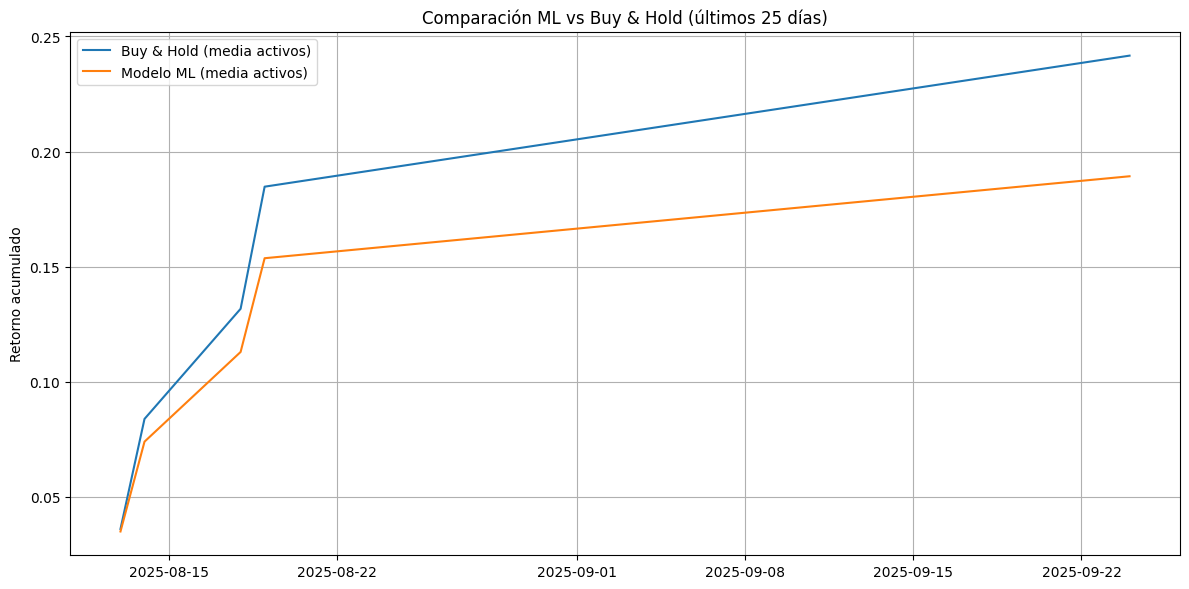

In [ ]:


# 6. Separar train y test (últimos 25 días del índice original)
cutoff = returns_train.index[-25]
train = panel.loc[panel.index.get_level_values("Date") < cutoff]
test  = panel.loc[panel.index.get_level_values("Date") >= cutoff]

# 7. Definir X e y para entrenamiento
features = ["ret_1m", "ret_3m", "ret_6m", "vol_1m", "vol_3m", "vol_6m"]
X_train = train[features]
y_train = train["target_21d"]

X_test = test[features]
y_test = test["target_21d"]

# 8. Escalar datos (solo con información de entrenamiento)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Entrenar un modelo supervisado (RandomForest)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# 10. Realizar predicciones sobre el conjunto de test
pred_test = model.predict(X_test_scaled)

# 11. Integrar predicciones al panel original de test
test = test.copy()
test["pred"] = pred_test

# 12. Crear señal binaria (comprar si predicción > 0)
test["signal"] = (test["pred"] > 0).astype(int)

# 13. Calcular rendimiento real si se aplica la señal
test["strategy_ret"] = test["signal"] * test["target_21d"]

# 14. Agregar resultados por fecha (sumar activos seleccionados)
daily_results = test.groupby("Date")[["target_21d", "strategy_ret"]].mean()

# 15. Graficar desempeño del modelo en los últimos 25 días
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_results.index, daily_results["target_21d"].cumsum(), label="Buy & Hold (media activos)")
plt.plot(daily_results.index, daily_results["strategy_ret"].cumsum(), label="Modelo ML (media activos)")
plt.title("Comparación ML vs Buy & Hold (últimos 25 días)")
plt.ylabel("Retorno acumulado")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Activos en el cluster 2 (Cartera Eficiente):
['NVDA', '3988.HK']


In [ ]:
#Preparación de features para clustering intradía
high = high_df
low  = low_df
close = close_df

intraday_vol = ((high - low) / close).mean()

features_intradia = pd.DataFrame({
    "intraday_vol": intraday_vol,
    "volume": volumen,
    "vol": desviacion  # podemos incluir volatilidad diaria también
}).dropna()

scaler_int = StandardScaler()
X_int = scaler_int.fit_transform(features_intradia)

kmeans_int = KMeans(n_clusters=3, random_state=42)
features_intradia["cluster_int"] = kmeans_int.fit_predict(X_int)


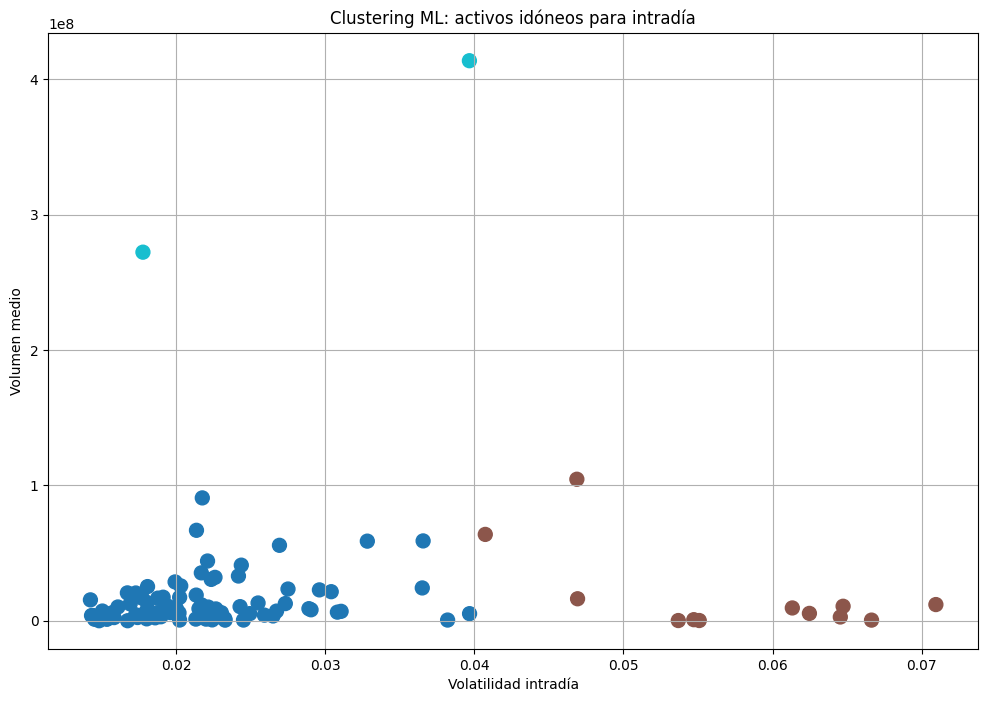

In [81]:
#Visualización del clustering intradía
plt.figure(figsize=(12, 8))

plt.scatter(
    features_intradia["intraday_vol"],
    features_intradia["volume"],
    c=features_intradia["cluster_int"],
    cmap="tab10",
    s=100
)

plt.xlabel("Volatilidad intradía")
plt.ylabel("Volumen medio")
plt.title("Clustering ML: activos idóneos para intradía")
plt.grid(True)
plt.show()
